## Section 1: Importing the Libraries

In [1]:
import time
import torch
#used to create the generator and discriminator
from torch import nn 
# used to create visualisations
import matplotlib.pyplot as plt 
# used to set size of visualisations
from matplotlib import rcParams 
#used to clear the visualisations at the end of each epoch
from IPython import display 
#saving outputs to the notebook
%matplotlib inline

## Creating the Data

The generated dataset approximates a linear relationship between two variables X and Y using the formula
$$Y = XA + b$$
which is simply a vectorized version of linear regression

#### Creating the dataset

In [2]:
X = torch.normal(0.0, 1, (1000, 2))
A = torch.tensor([[1, 2], [-0.1, 0.5]])
b = torch.tensor([1, 2])
data = torch.matmul(X, A) + b

#### Display dataset

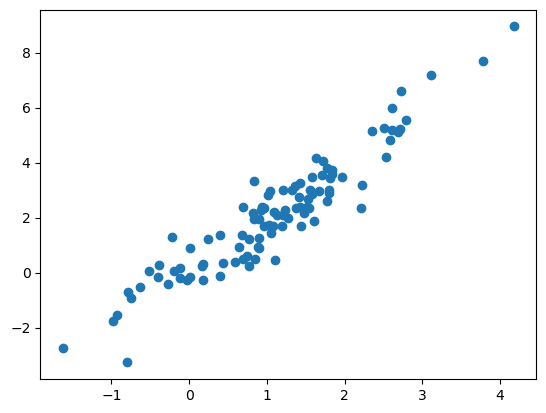

In [3]:
plt.scatter(data[:100, 0].detach().numpy(), data[:100, 1].detach().numpy())

#### Creating Dataset Iterateables

In [4]:
batch_size = 8
dataset = torch.utils.data.TensorDataset(data)
data_iter = torch.utils.data.DataLoader(dataset, batch_size, shuffle=True)


## Section 2: The Model
### Generators and Discriminators
The generator needs to be trained to generator the discriminator cannot classify as fake. Sine the dataset is created using linear rigression, we use a single layered neural network.

![alt text](images/generator.png "Generator")

The discriminator is a slightly more complex neural network since it has to learn to classify the generated examples as real or fake.

![alt text](images/discriminator.png "Discriminator")

#### Generator Neural Net

In [5]:
nnet_Gen = nn.Sequential(nn.Linear(2, 2))

#### Discriminator Neural Net

In [6]:
nnet_Disc = nn.Sequential(
  nn.Linear(2, 5), nn.Tanh(),
  nn.Linear(5, 3), nn.Tanh(),
  nn.Linear(3, 1))

### Discriminator Updates

we use the real and synthetic batches to compute the loss by computing the loss on the discriminator outputs for real batch with a tensor of ones which denote real samples, and for synthetic batch with a tensor of zeroes which denote fakes. The final loss is an average of the two, since the discriminator's job is to correctly classify the two distributions as separate.

In [7]:
"""
X is the training batch
Z is the seed values for the fake batch
nnet_D is the discriminator neural net
nnet_G is the generator neural net
loss is the loss function
trainer_d is the optimizer
"""
def update_D(X, Z, nnet_D, nnet_G, loss, trainer_D):
    batch_size = X.shape[0]
    ones = torch.ones((batch_size,), device=X.device)
    zeros = torch.zeros((batch_size,), device=X.device)
    trainer_D.zero_grad()
    real_Y = nnet_D(X)
    synth_X = nnet_G(Z)
    synth_Y = nnet_D(synth_X.detach())
    loss_D = (loss(real_Y, ones.reshape(real_Y.shape)) +
              loss(synth_Y, zeros.reshape(synth_Y.shape))) / 2
    loss_D.backward()
    trainer_D.step()
    return loss_D


### Generator Updates

We use the noise given as input to generate a synthetic batch and make predictions using the discriminator then compute the loss on these predictions with ones (to fool the discriminator better), compute the gradients, and perform updates. 

In [8]:
"""
Z is the noise vector for generating fake branch
nnet_D is the discriminator neural net
nnet_G is the generator neural net
loss is the loss function
trainer_G is the optimizer
"""
def update_G(Z, nnet_D, nnet_G, loss, trainer_G):
    batch_size = Z.shape[0]
    ones = torch.ones((batch_size,), device=Z.device)
    trainer_G.zero_grad()
    synth_X = nnet_G(Z)
    synth_Y = nnet_D(synth_X)
    loss_G = loss(synth_Y, ones.reshape(synth_Y.shape))
    loss_G.backward()
    trainer_G.step()
    return loss_G


## Section 3: The Train Function
### Initialize the Parameters

We initialize the loss as an instance of the BCEWithLogitsLoss class, which combines a Sigmoid layer and the BCELoss in one single class. We also initialize the optimizers for both the generator and discriminator using the Adam optimizer. the init() function takes the parameters as tensor, mean, and standard deviation to initialize the weights of the neural networks. The Adam optimizer takes parameters of the model to optimize and the learning rate. This gives an output as two empty lists to store the losses of the generator and discriminator.

In [9]:
"""
Discriminator is the discriminator neural net
Generator is the generator neural net
lr_D is the learning rate for the discriminator
lr_G is the learning rate for the generator
"""

"""
loss is the loss function
trainer_D is the optimizer for the discriminator
trainer_G is the optimizer for the generator
fig is the figure for visualisations
axes is the axes for plotting the visualisations
loss_D is the list of discriminator losses
loss_G is the list of generator losses
"""

def init_params(Discriminator, Generator, lr_D, lr_G):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in Discriminator.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in Generator.parameters():
        nn.init.normal_(w, 0, 0.02)
    trainer_D = torch.optim.Adam(Discriminator.parameters(), lr=lr_D)
    trainer_G = torch.optim.Adam(Generator.parameters(), lr=lr_G)
    fig, axes = plt.subplots(2, 1, figsize=(5, 9))
    loss_D = []
    loss_G = []

    return loss, trainer_D, trainer_G, fig, axes, loss_D, loss_G



### Task 7: Compute the Losses

We define the function for computing the losses of the generator and discriminator neural nets, which initialises a noise array, computes the losses, and aggregates them into an array.

In [10]:
"""
X is the input batch of samples.
net_D is the discriminator neural net
net_G is the generator neural net
loss is the loss function to be optimized
trainer_D is the discriminator optimizer
trainer_G is the generator optimizer
batch_size id the number of samples concurrently processed
latent_dim is the number of output features of the generator
data_iter is the dataset iterator previously created
"""

"""
metrics is the array which stores the losses of the generator and discriminator with the batch size
"""

def compute_losses(X, net_D, net_G, loss, trainer_D, trainer_G, batch_size, latent_dim, data_iter):
    metrics = [0.0]*3 
    for (X,) in data_iter:
        batch_size = X.shape[0]
        Z = torch.normal(0, 1, size=(batch_size, latent_dim))
        metric = [update_D(X, Z, net_D, net_G, loss, trainer_D),
                    update_G(Z, net_D, net_G, loss, trainer_G),
                    batch_size]
        metrics = [sum(i) for i in zip(metric, metrics)]

    return metrics

### Display Generated Distributions

Here we define the method for displaying the data distribution generated by the generator at each epoch. We initialise a noise array, use it to generate a synthetic batch, and plot the real and synthetic batches in a scatterplot

In [11]:
"""
net_G is the neural net of the generator
axes is the array of axes previously created
latent_dim is the number of input features of the neural net of the generator previously defined
"""
def display_gen_dist(net_G, axes, latent_dim, data):
    Z = torch.normal(0, 1, size=(100, latent_dim))
    synth_X = net_G(Z).detach().numpy()
    axes[1].cla()
    axes[1].scatter(data[:, 0], data[:, 1])
    axes[1].scatter(synth_X[:, 0], synth_X[:, 1])
    axes[1].legend(['real', 'generated'])


### Display the losses

We define the method for displaying the losses of the discriminator and generator neural nets, which will be plotted in each epoch as a line plot on the same axes.

In [12]:
"""
metrics contains the accumulated losses of the discriminator and generator with the batch size
loss_D is the loss of the discriminator neural net
loss_G is the loss of the generator neural net
axes is the axes on which the plot will be drawn
fig is the figure on which the plot will be made
epoch is the epoch number at which function is called
"""


"""
loss_D is the loss of the discriminator neural net
loss_G is the loss of the generator neural net
"""
def display_losses(metrics, loss_D, loss_G, axes, fig, epoch):
    D = metrics[0]/metrics[2]
    loss_D.append(D.detach())
    G = metrics[1]/metrics[2]
    loss_G.append(G.detach())
    axes[0].plot(range(epoch+1), loss_D, c="blue")
    axes[0].plot(range(epoch+1), loss_G, c="green")
    axes[0].legend(['Discriminator loss', 'Generator loss'])
    display.display(fig)
    display.clear_output(wait=True)

    return loss_D, loss_G


### Create the Training Function

We first start a timer to measure the time taken for training and initialise the parameters created earlier. Then, for each epoch, we iterate through the dataset, updating the discriminator and generator in each iteration. After each epoch, we compute the losses and display the generated distributions and losses.

In [13]:
"""
net_D is the neural net of the discriminator
net_G is the neural net of the generator
data_iter is the dataset iterator previously created
num_epochs is the number of epochs for which the model is to be trained
lr_D is the learning rate for the discriminator
lr_G is the learning rate for the generator
latent_dim is the number of output features of the generator
data is the original data
"""
def train(net_D, net_G, data_iter, num_epochs, lr_D, lr_G, latent_dim, data):
    # Start timer
    tik = time.perf_counter()
    # Init variables
    loss, trainer_D, trainer_G, fig, axes, loss_D, loss_G = init_params(net_D, net_G, lr_D, lr_G)
    for epoch in range(num_epochs):
        # Train one epoch
        metrics = compute_losses(X, net_D, net_G, loss, trainer_D, trainer_G, batch_size, latent_dim, data_iter)
        # Visualize generated examples
        display_gen_dist(net_G, axes, latent_dim, data)
        # Show the losses
        loss_D, loss_G = display_losses(metrics, loss_D, loss_G, axes, fig, epoch)
    # End timer
    tok = time.perf_counter()
    # Display stats
    print(f'loss_D {loss_D[-1]}, loss_G {loss_G[-1]}, {(metrics[2]*num_epochs) / (tok-tik):.1f} examples/sec')

### Train the model

loss_D 0.6931614875793457, loss_G 0.6930911540985107, 2704.7 examples/sec


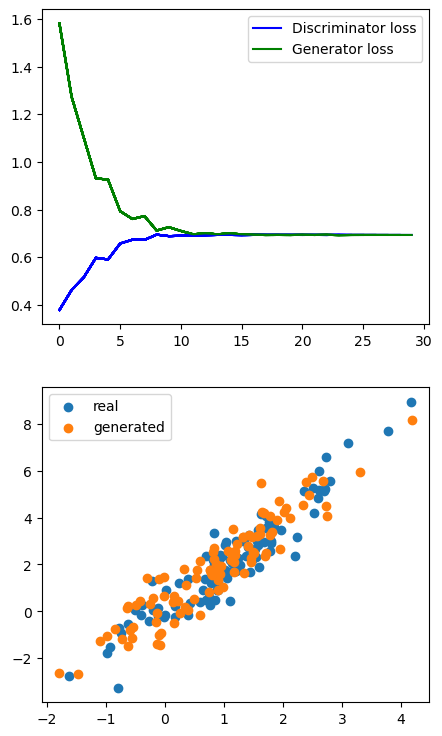

In [14]:
lr_D, lr_G, latent_dim, num_epochs = 0.05, 0.005, 2, 30
train(nnet_Disc, nnet_Gen, data_iter, num_epochs, lr_D, lr_G, latent_dim, data[:100].detach().numpy())